In [14]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from geopy.distance import geodesic
import os

def calculate_distance_from_point_to_station(row):
    station_coord = (row['LATITUDE:'], row['LONGITUDE:'])
    given_point_coord = (-15.760063, -47.871154)

    return geodesic(station_coord, given_point_coord).kilometers

df_all_stations = pd.read_csv("../data/all_stations.csv", decimal=",", sep=";")

df_all_stations["Distancia"] = df_all_stations.apply(calculate_distance_from_point_to_station, axis=1) 

df_nearest_stations = df_all_stations[(df_all_stations["Distancia"] < 35)] 

print(df_nearest_stations)

    REGI?O: UF:           ESTAC?O: CODIGO (WMO):     LATITUDE:    LONGITUDE:  \
141      CO  DF         BRAZLANDIA          A042  -15.59972221   -48.1311111   
233      CO  DF    AGUAS EMENDADAS          A045    -15.596491    -47.625801   
239      CO  DF  GAMA (PONTE ALTA)          A046  -15.93527777  -48.13749999   
442      CO  DF           BRASILIA          A001    -15.789343    -47.925756   

    ALTITUDE:                                            Arquivo  Distancia  
141    1143.0  INMET_CO_DF_A042_BRAZLANDIA_01-01-2019_A_31-12...  33.036886  
233   1030.36  INMET_CO_DF_A045_AGUAS EMENDADAS_01-01-2019_A_...  31.928860  
239     990.0  INMET_CO_DF_A046_GAMA (PONTE ALTA)_01-01-2019_...  34.494431  
442   1160.96  INMET_CO_DF_A001_BRASILIA_01-01-2019_A_31-12-2...   6.688014  


In [15]:
yeardirectoryfilename = []
df_nearest_stations_weather_data = []

for filename in df_nearest_stations['Arquivo']: 
    yeardirectoryfilename.append(filename)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2019_cleaned/{filename}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2020_cleaned/{filename.replace("2019", "2020")}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2021_cleaned/{filename.replace("2019", "2021")}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2022_cleaned/{filename.replace("2019", "2022")}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2023_cleaned/{filename.replace("2019", "2023")}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

    df_weather_data = pd.read_csv(f'../data/cleaned_data/2024_cleaned/{filename.replace("2019", "2024")}', decimal=".", sep=";")
    df_weather_data.rename(columns={'RADIACAO GLOBAL (Kj/m²)': 'RADIACAO GLOBAL (KJ/m²)'}, inplace=True)
    df_nearest_stations_weather_data.append(df_weather_data)

df_compilation_of_nearest_stations_weather_data = pd.concat(df_nearest_stations_weather_data, ignore_index= True)


df_compilation_of_nearest_stations_weather_data

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (KJ/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)"
0,2019/01/01,0000 UTC,0.0,888.4,888.4,887.7,NaN,18.7,17.4,19.4,18.6,17.4,17.1,92.0,87.0,92.0,329.0,5.3,1.2
1,2019/01/01,0100 UTC,0.2,889.0,889.0,888.4,NaN,19.0,17.5,19.0,18.5,17.5,17.3,93.0,91.0,91.0,67.0,3.3,2.0
2,2019/01/01,0200 UTC,0.2,889.2,889.2,889.0,NaN,18.9,17.4,19.0,18.8,17.5,17.4,92.0,91.0,91.0,37.0,3.3,1.4
3,2019/01/01,0300 UTC,0.0,888.6,889.2,888.6,NaN,18.6,16.8,19.0,18.6,17.4,16.7,91.0,87.0,89.0,24.0,2.6,0.9
4,2019/01/01,0400 UTC,0.0,887.9,888.6,887.9,NaN,18.6,17.2,18.7,18.4,17.3,16.8,93.0,89.0,91.0,21.0,2.4,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210427,2024/12/31,1900 UTC,0.0,884.5,885.0,884.5,2061.5,26.3,18.2,26.7,25.4,18.9,16.6,65.0,56.0,61.0,351.0,6.3,3.3
210428,2024/12/31,2000 UTC,0.0,884.1,884.5,884.0,1940.0,26.2,17.7,26.7,25.8,18.4,17.2,62.0,58.0,59.0,348.0,7.4,3.7
210429,2024/12/31,2100 UTC,0.0,884.3,884.4,884.1,877.0,21.7,18.9,26.3,21.6,19.0,17.3,84.0,59.0,84.0,3.0,12.1,3.4
210430,2024/12/31,2200 UTC,0.0,884.5,884.5,884.1,109.8,21.3,19.4,21.8,21.2,19.4,18.8,89.0,84.0,89.0,356.0,5.3,2.5


            PRECIPITAÇÃO TOTAL, HORÁRIO (mm)  \
datetime                                       
2019-01-01                          0.070833   
2019-01-02                          0.000000   
2019-01-03                          0.033333   
2019-01-04                          0.000000   
2019-01-05                          0.725000   
...                                      ...   
2024-12-08                          0.000000   
2024-12-09                          0.000000   
2024-12-10                          0.173626   
2024-12-11                          0.241758   
2024-12-12                          0.222472   

            PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)  \
datetime                                                            
2019-01-01                                         895.962500       
2019-01-02                                         894.972917       
2019-01-03                                         896.056250       
2019-01-04                    

/tmp/ipykernel_436803/2600641866.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_numeric.resample('M').mean()
/tmp/ipykernel_436803/2600641866.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly[target_column] = target_hourly.resample('M').max()


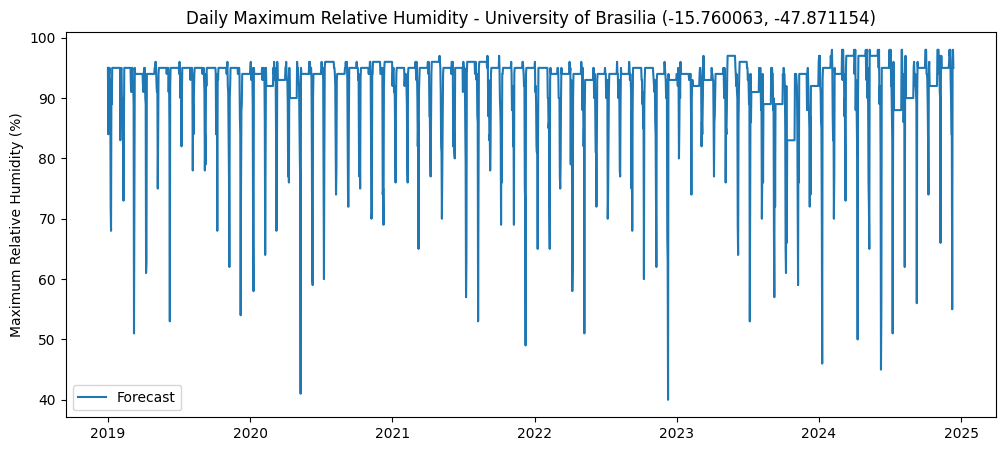

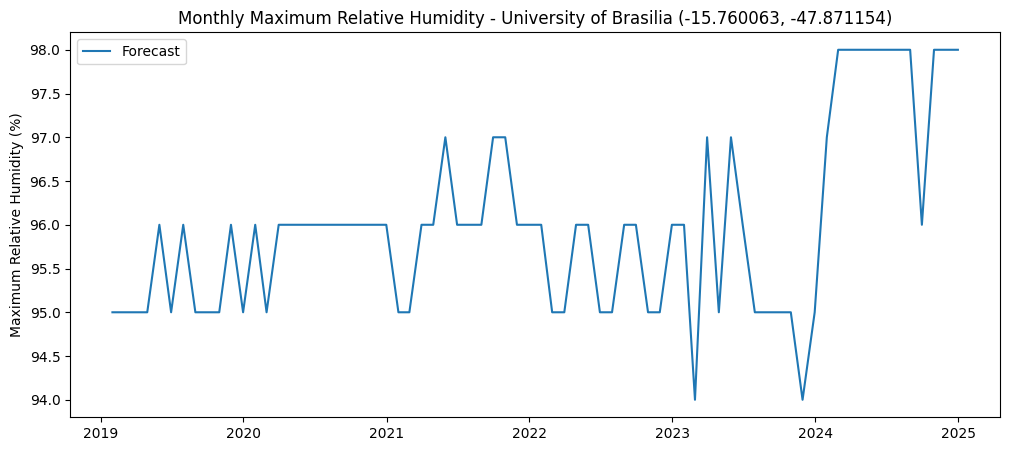

PRECIPITAÇÃO TOTAL, HORÁRIO (mm)                         0
PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)    0
PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)          0
PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)         0
RADIACAO GLOBAL (KJ/m²)                                  0
TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)             0
TEMPERATURA DO PONTO DE ORVALHO (°C)                     0
TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)               0
TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)               0
TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)         0
TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)         0
UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)                 0
UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)                 0
UMIDADE RELATIVA DO AR, HORARIA (%)                      0
VENTO, DIREÇÃO HORARIA (gr) (° (gr))                     0
VENTO, RAJADA MAXIMA (m/s)                               0
VENTO, VELOCIDADE HORARIA (m/s)                         

In [16]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error

forecast_parameter = 'UMIDADE RELATIVA DO AR, HORARIA (%)'

def _extract_hour_from_hora_utc(series):
    hour_str = series.astype(str).str.extract(r'^\s*(\d{2})')[0]
    hour = pd.to_numeric(hour_str, errors='coerce').fillna(0).clip(0, 23).astype(int)
    return hour

def prepare_daily_and_monthly_max_humidity(dataframe, target_column):
    # Build hourly datetime index and keep chronological order.
    df = dataframe.copy()
    df['Data'] = pd.to_datetime(df['Data'], dayfirst=True, errors='coerce')
    df['hour'] = _extract_hour_from_hora_utc(df['Hora UTC'])
    df['datetime'] = df['Data'] + pd.to_timedelta(df['hour'], unit='h')
    df = df.dropna(subset=['datetime']).sort_values('datetime').set_index('datetime')

    # Keep numeric weather variables for daily/monthly aggregation.
    df_numeric = df.drop(columns=['Data', 'Hora UTC', 'hour'])

    # Target is reported for the previous hour, so align its timestamp first.
    target_hourly = df_numeric[target_column].copy()

    # Daily and monthly exogenous summaries.
    df_daily = df_numeric.resample('D').mean()
    df_monthly = df_numeric.resample('M').mean()

    # Daily/monthly target as maximum relative humidity after temporal alignment.
    df_daily[target_column] = target_hourly.resample('D').max()
    df_monthly[target_column] = target_hourly.resample('M').max()

    df_daily = df_daily.ffill().dropna(subset=[target_column])
    df_monthly = df_monthly.ffill().dropna(subset=[target_column])

    return df_daily, df_monthly


df_avarage_humidity_by_day, df_avarage_humidity_by_month = prepare_daily_and_monthly_max_humidity(
    df_compilation_of_nearest_stations_weather_data,
    forecast_parameter,
)

print(df_avarage_humidity_by_day)

plt.figure(figsize=(12, 5))
plt.plot(df_avarage_humidity_by_day[forecast_parameter], label='Forecast')
plt.title('Daily Maximum Relative Humidity - University of Brasilia (-15.760063, -47.871154)')
plt.ylabel('Maximum Relative Humidity (%)')
plt.legend()

plt.figure(figsize=(12, 5))
plt.plot(df_avarage_humidity_by_month[forecast_parameter], label='Forecast')
plt.title('Monthly Maximum Relative Humidity - University of Brasilia (-15.760063, -47.871154)')
plt.ylabel('Maximum Relative Humidity (%)')
plt.legend()
plt.show()

print(df_avarage_humidity_by_day.isnull().sum())

df_not_null_values_day = df_avarage_humidity_by_day.ffill()
df_not_null_values_month = df_avarage_humidity_by_month.ffill()

df_splited_data = int(len(df_not_null_values_day) * 0.8)
df_training, df_test = df_not_null_values_day[:df_splited_data], df_not_null_values_day[df_splited_data:]

print(df_training)

df_splited_data_month = int(len(df_not_null_values_month) * 0.8)
df_training_month, df_test_month = df_not_null_values_month[:df_splited_data_month], df_not_null_values_month[df_splited_data_month:]



<Figure size 1000x500 with 0 Axes>

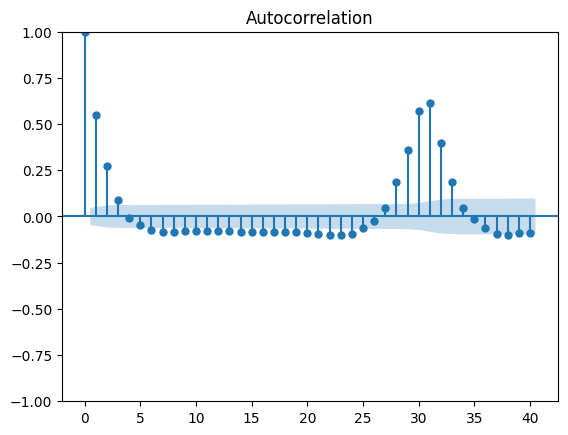

<Figure size 1000x500 with 0 Axes>

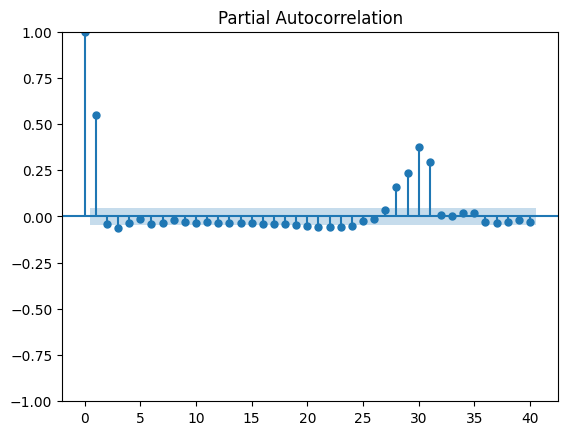

/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/juliab

    p  d  q           AIC
42  2  2  2     10.000000
33  2  0  1  10831.726700
49  3  0  1  10833.095804
34  2  0  2  10833.108587
50  3  0  2  10835.017533
.. .. .. ..           ...
13  0  3  1  12793.603392
60  3  3  0  12814.029328
44  2  3  0  13109.019764
28  1  3  0  13635.408494
12  0  3  0  14728.875773

[64 rows x 4 columns]
\begin{tabular}{rrrr}
\toprule
p & d & q & AIC \\
\midrule
2 & 2 & 2 & 10.00 \\
2 & 0 & 1 & 10831.73 \\
3 & 0 & 1 & 10833.10 \\
2 & 0 & 2 & 10833.11 \\
3 & 0 & 2 & 10835.02 \\
2 & 0 & 3 & 10835.05 \\
3 & 0 & 3 & 10837.05 \\
3 & 1 & 2 & 10849.74 \\
3 & 0 & 0 & 10850.78 \\
3 & 1 & 1 & 10851.33 \\
0 & 0 & 3 & 10851.34 \\
1 & 0 & 3 & 10852.70 \\
1 & 0 & 2 & 10852.89 \\
1 & 1 & 3 & 10853.46 \\
2 & 0 & 0 & 10855.49 \\
2 & 1 & 1 & 10856.06 \\
1 & 0 & 1 & 10856.06 \\
1 & 1 & 2 & 10856.63 \\
1 & 0 & 0 & 10856.66 \\
1 & 1 & 1 & 10857.21 \\
2 & 1 & 3 & 10860.55 \\
2 & 1 & 2 & 10861.12 \\
3 & 1 & 3 & 10861.57 \\
1 & 2 & 3 & 10869.65 \\
1 & 2 & 2 & 10869.69 \\
3 & 2 & 2

In [17]:
# Seleção da série diária
series_day = df_training[forecast_parameter]

# Gráficos de Autocorrelação e Autocorrelação Parcial 
plt.figure(figsize=(10, 5))
plot_acf(series_day, lags=40)
plt.title('Autocorrelation')
plt.show()

plt.figure(figsize=(10, 5))
plot_pacf(series_day, lags=40, method='ywm')
plt.title('Partial Autocorrelation')
plt.show()

import itertools

# Definição dos ranges dos hiperparâmetros
p = range(0, 4)
d = range(0, 4)
q = range(0, 4)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None

results = []

for order in pdq:
    try:
        model = ARIMA(series_day, order=order)
        model_fit = model.fit()
        aic = model_fit.aic
        results.append({'p': order[0], 'd': order[1], 'q': order[2], 'AIC': aic})
        if aic < best_aic:
            best_aic = aic
            best_order = order
    except Exception as e:
        results.append({'p': order[0], 'd': order[1], 'q': order[2], 'AIC': None})
        continue

# Criação do DataFrame
df_grid = pd.DataFrame(results)
df_grid = df_grid.dropna(subset=['AIC'])
df_grid = df_grid.sort_values(by='AIC')

# Imprimir todas as configurações ordenadas pelo menor AIC
print(df_grid)

# Export da tabela
print(df_grid.to_latex(index=False, float_format="%.2f"))

print(f"Melhor configuração (p,d,q): {best_order} com AIC={best_aic}")


MSE: 66.23280575531491
RMSE: 8.13835399545356
SMAPE: 5.72942055672438


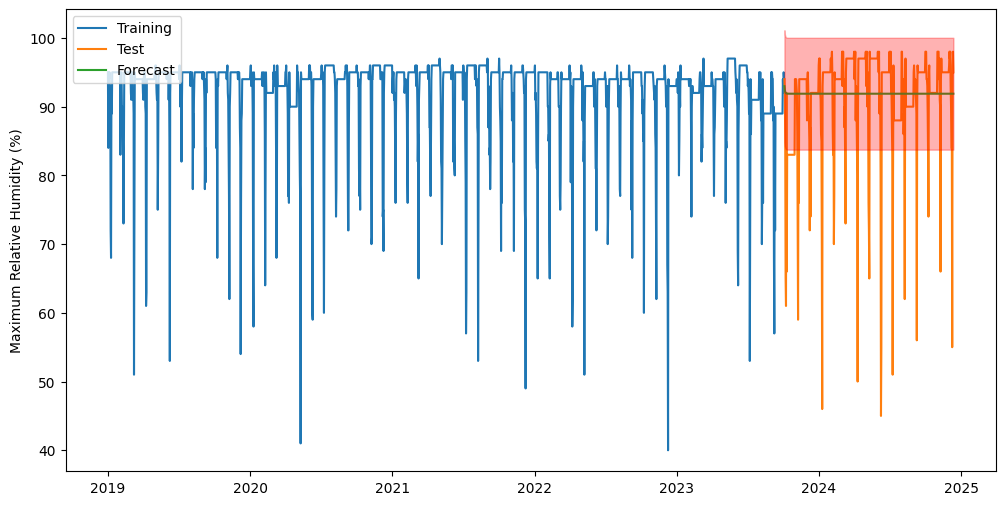

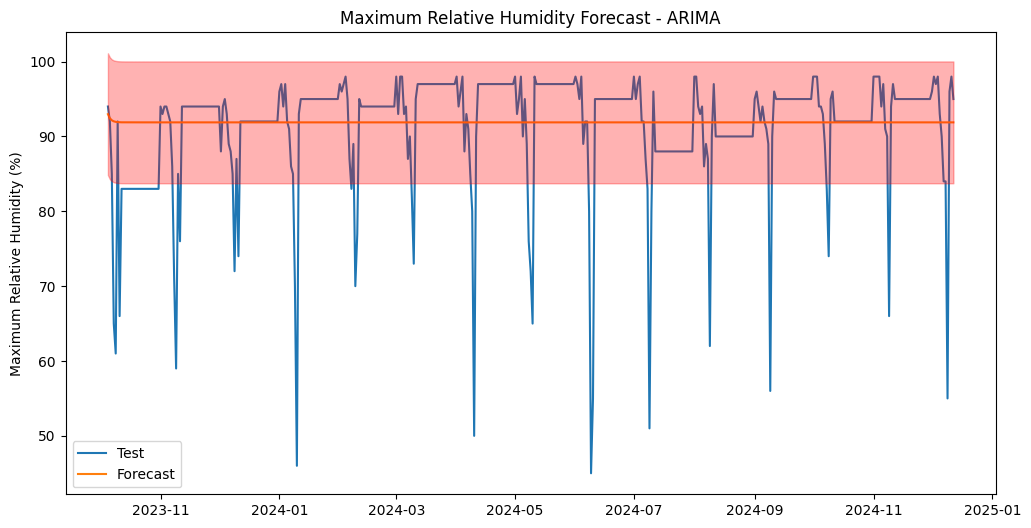

In [18]:
# Ajuste do modelo ARIMA
model = ARIMA(df_training[forecast_parameter], order=(2, 1, 3))
model_fit = model.fit()

# Previsões
forecast = model_fit.forecast(steps=len(df_test))

# Visualização das previsões
plt.figure(figsize=(12,6))
plt.plot(df_training.index, df_training[forecast_parameter], label='Training')
plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
plt.plot(df_test.index, forecast, label='Forecast')
plt.ylabel('Maximum Relative Humidity (%)')
plt.legend(loc='upper left')

# Cálculo RMSE
mse = mean_squared_error(df_test[forecast_parameter], forecast)
rmse = mse**0.5 
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
plt.fill_between(df_test.index, (forecast-rmse), (forecast+rmse), alpha=.3, color='r', zorder=20)

# Gráfico de previsões
plt.figure(figsize=(12,6))
plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
plt.plot(df_test.index, forecast, label='Forecast')
plt.ylabel('Maximum Relative Humidity (%)')
plt.legend(loc='upper left')
plt.title(f"Maximum Relative Humidity Forecast - ARIMA")
plt.legend()
plt.fill_between(df_test.index, (forecast-rmse), (forecast+rmse), alpha=.3, color='r', zorder=20)

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))

smape_value = smape(df_test[forecast_parameter], forecast)
print(f"SMAPE: {smape_value}")


MSE: 66.23280575531491
RMSE: 8.13835399545356
SMAPE: 5.73%


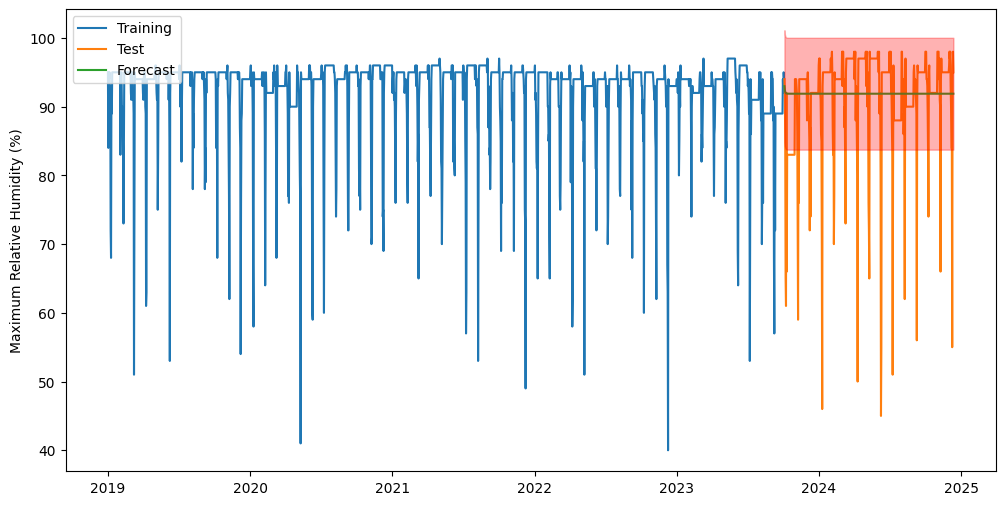

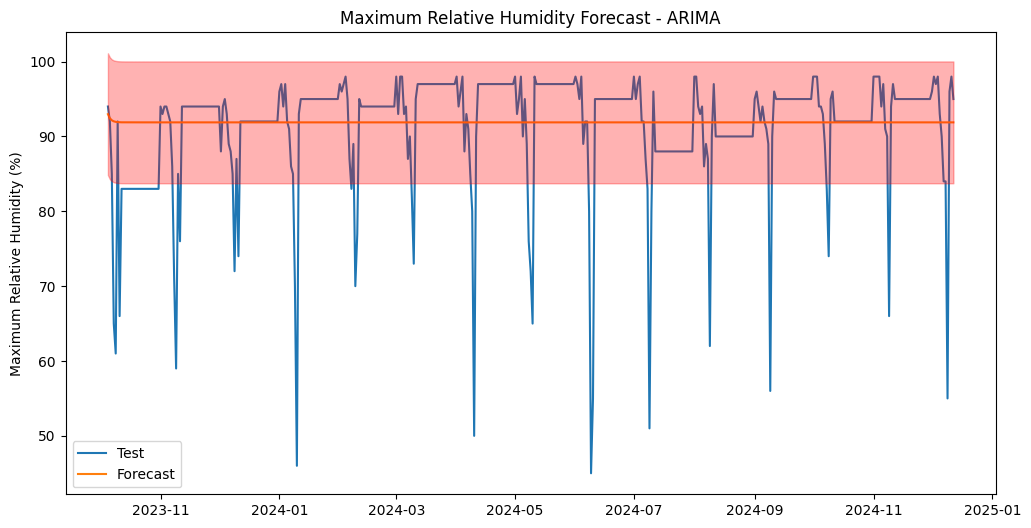

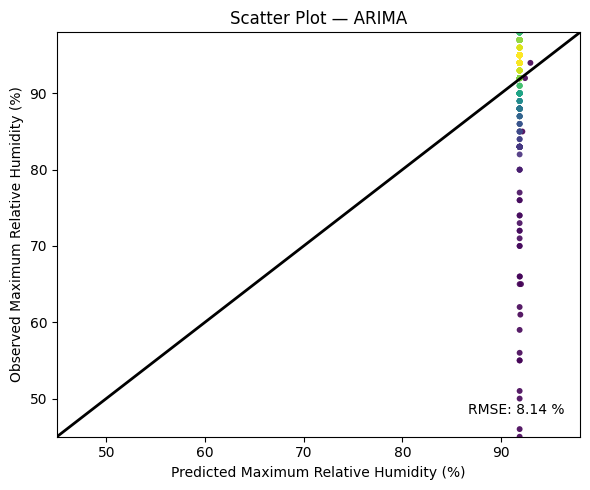

In [19]:
# Ajuste do modelo ARIMA
model = ARIMA(df_training[forecast_parameter], order=(2, 1, 3))
model_fit = model.fit()

# Fazer previsões
forecast = model_fit.forecast(steps=len(df_test))

# Visualização das previsões 
plt.figure(figsize=(12,6))
plt.plot(df_training.index, df_training[forecast_parameter], label='Training')
plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
plt.plot(df_test.index, forecast, label='Forecast')
plt.ylabel('Maximum Relative Humidity (%)')
plt.legend(loc='upper left')

# Cálculo RMSE
mse = mean_squared_error(df_test[forecast_parameter], forecast)
rmse = mse**0.5 
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
plt.fill_between(df_test.index, (forecast-rmse), (forecast+rmse), alpha=.3, color='r', zorder=20)

plt.figure(figsize=(12,6))
plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
plt.plot(df_test.index, forecast, label='Forecast')
plt.ylabel('Maximum Relative Humidity (%)')
plt.legend(loc='upper left')
plt.title("Maximum Relative Humidity Forecast - ARIMA")
plt.legend()
plt.fill_between(df_test.index, (forecast-rmse), (forecast+rmse), alpha=.3, color='r', zorder=20)

# Cáculo sMAPE
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))

smape_value = smape(df_test[forecast_parameter], forecast)
print(f"SMAPE: {smape_value:.2f}%")

# Gráfico de dispersão 
y_true = df_test[forecast_parameter].to_numpy()
y_pred = np.asarray(forecast).ravel()

vmin = float(np.floor(min(y_true.min(), y_pred.min())))
vmax = float(np.ceil(max(y_true.max(), y_pred.max())))

fig, ax = plt.subplots(figsize=(6,5))

try:
    from scipy.stats import gaussian_kde
    xy = np.vstack([y_pred, y_true])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    ax.scatter(y_pred[idx], y_true[idx], c=z[idx], s=18, alpha=0.9,
               cmap="viridis", edgecolor="none")
except Exception:
    hb = ax.hexbin(y_pred, y_true, gridsize=35,
                   extent=[vmin, vmax, vmin, vmax],
                   cmap="viridis", mincnt=1)
    fig.colorbar(hb, ax=ax, label="Density")

ax.plot([vmin, vmax], [vmin, vmax], 'k-', lw=2)  # linha x=y
ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)
ax.set_xlabel("Predicted Maximum Relative Humidity (%)")
ax.set_ylabel("Observed Maximum Relative Humidity (%)")
ax.set_title("Scatter Plot — ARIMA")
ax.text(0.97, 0.05, f"RMSE: {rmse:.2f} %", ha="right", va="bottom",
        transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.show()


/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.60180D-01    |proj g|=  2.01530D-01

At iterate    5    f=  8.87688D-01    |proj g|=  2.02061D-02

At iterate   10    f=  8.85126D-01    |proj g|=  2.06670D-03

At iterate   15    f=  8.85070D-01    |proj g|=  6.74256D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     17     19      1     0     0   7.441D-06   8.851D-01
  F =  0.88506995082480078     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


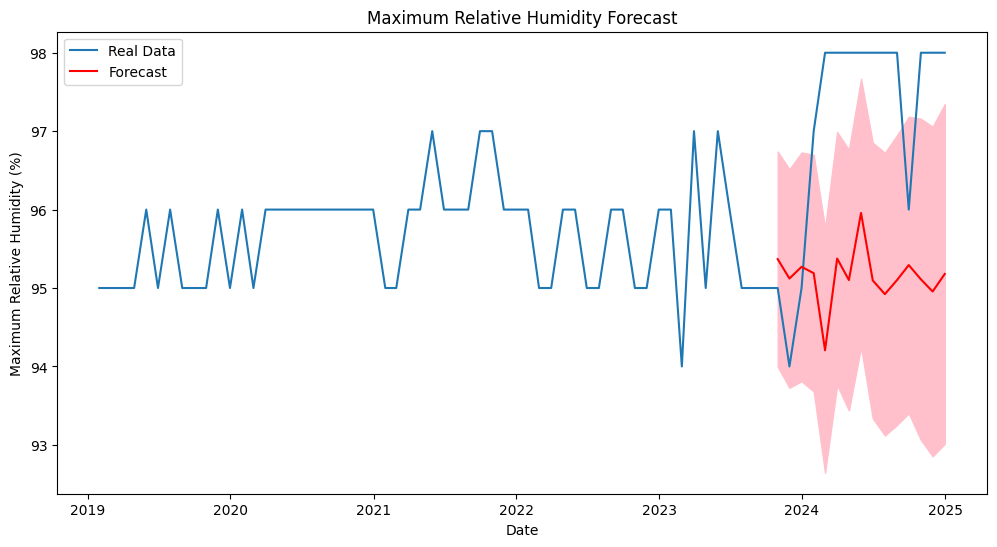

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define os parametros 
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 12  # Assuming monthly seasonality

# Fit SARIMA model
model = SARIMAX(df_training_month[forecast_parameter], order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()

# Previsão
forecast_periods =  int(len(df_test_month[forecast_parameter]))  # Forecast the next 12 months
forecast = results.get_forecast(steps=forecast_periods)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Gráfico da previsão
plt.figure(figsize=(12, 6))
plt.plot(df_not_null_values_month[forecast_parameter], label='Real Data')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink')
plt.title("Maximum Relative Humidity Forecast")
plt.xlabel("Date")
plt.ylabel("Maximum Relative Humidity (%)")
plt.legend()
plt.show()




/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MSE: 67.17474799110171
RMSE: 8.196020253214465
datetime
2023-10-05    94.0
2023-10-06    92.0
2023-10-07    85.0
2023-10-08    65.0
2023-10-09    61.0
              ... 
2024-12-08    84.0
2024-12-09    55.0
2024-12-10    96.0
2024-12-11    98.0
2024-12-12    95.0
Freq: D, Name: UMIDADE RELATIVA DO AR, HORARIA (%), Length: 435, dtype: float64
SMAPE: 5.713028954424277
File saved at: /home/juliababa/tcc/src/forecast_arima_fourier_umidade_maxima.csv
         data  observed_humidity_max  predicted_humidity_max
0  2023-10-05                   94.0                  93.375
1  2023-10-06                   92.0                  93.001
2  2023-10-07                   85.0                  92.966
3  2023-10-08                   65.0                  92.923
4  2023-10-09                   61.0                  92.995


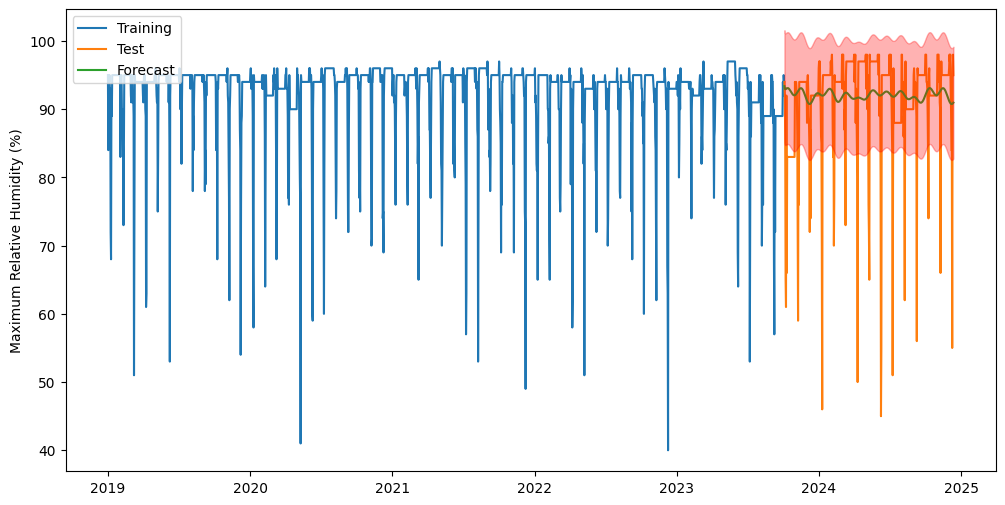

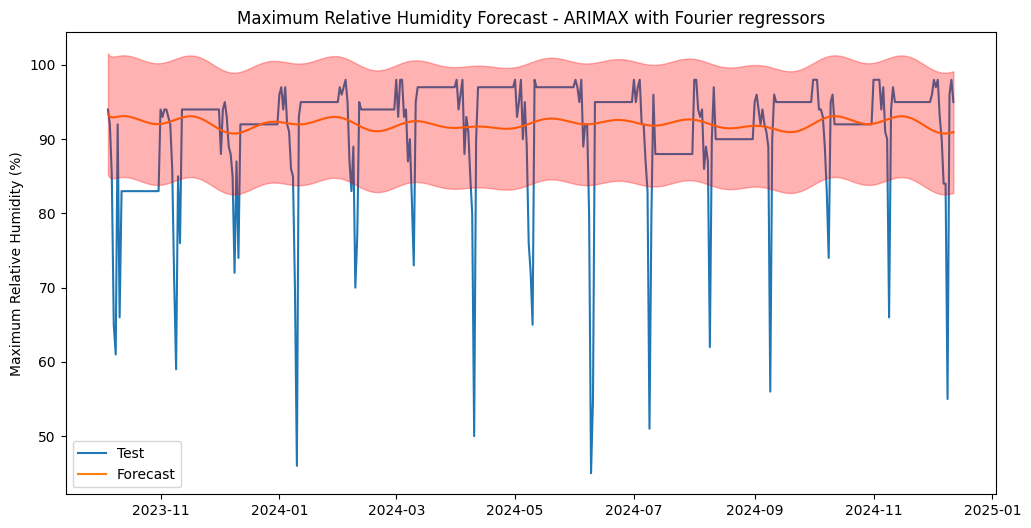

In [21]:
n = len(df_training[forecast_parameter])  
t = np.arange(n)
seasonality = 365  

# Cria os termos de Fourier
def create_fourier_terms(t, period, num_terms):
    terms = []
    for i in range(1, num_terms + 1):
        terms.append(np.sin(2 * np.pi * i * t / period))
        terms.append(np.cos(2 * np.pi * i * t / period))
    return np.column_stack(terms)

num_fourier_terms = 10
fourier_terms = create_fourier_terms(t, seasonality, num_fourier_terms)

# Fit ARIMA model usando termos de Fourier como variáveis exógenas
model = ARIMA(df_training[forecast_parameter],exog=fourier_terms[:n], order=(2, 1, 3))
model_fit = model.fit()

# Prepara os termos de Fourier para o período de previsão
forecast_exog = create_fourier_terms(np.arange(n, n + len(df_test)), seasonality, num_fourier_terms)

# Prepare o DataFrame de variáveis exógenas para previsão
forecast_df = pd.DataFrame(forecast_exog, columns=[f'Fourier_{i+1}' for i in range(num_fourier_terms * 2)])

# Faz as previsões
forecast = model_fit.forecast(steps=len(df_test), exog=forecast_df)

# Visualização das previsões
plt.figure(figsize=(12,6))
plt.plot(df_training.index, df_training[forecast_parameter], label='Training')
plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
plt.plot(df_test.index, forecast, label='Forecast')
plt.ylabel('Maximum Relative Humidity (%)')
plt.legend(loc='upper left')

# Cálculo metricas de erro
mse = mean_squared_error(df_test[forecast_parameter], forecast)
rmse = mse**0.5 
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
plt.fill_between(df_test.index, (forecast-rmse), (forecast+rmse), alpha=.3, color='r', zorder=20)

plt.figure(figsize=(12,6))
plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
plt.plot(df_test.index, forecast, label='Forecast')
plt.ylabel('Maximum Relative Humidity (%)')
plt.legend(loc='upper left')
plt.title(f"Maximum Relative Humidity Forecast - ARIMAX with Fourier regressors")
plt.legend()
plt.fill_between(df_test.index, (forecast-rmse), (forecast+rmse), alpha=.3, color='r', zorder=20)


print(df_test[forecast_parameter])

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))

smape_value = smape(df_test[forecast_parameter], forecast)
print(f"SMAPE: {smape_value}")

from pathlib import Path

idx = forecast.index
try:
    idx = idx.tz_localize(None)
except Exception:
    pass

# Monta o DataFrame de saída
df_out = pd.DataFrame({
    "data": pd.to_datetime(idx).strftime("%Y-%m-%d"),
    "observed_humidity_max": df_test.loc[forecast.index, forecast_parameter].to_numpy(),
    "predicted_humidity_max": forecast.to_numpy()
})

# Arredonda os valores para 3 casas decimais
df_out["observed_humidity_max"] = df_out["observed_humidity_max"].round(3)
df_out["predicted_humidity_max"] = df_out["predicted_humidity_max"].round(3)

# Caminho do arquivo
saida = Path("forecast_arima_fourier_umidade_maxima.csv")

# Salva com separador ';' 
df_out.to_csv(saida, sep=";", index=False, encoding="utf-8-sig")

print(f"File saved at: {saida.resolve()}")
print(df_out.head())

MSE: 67.22575400162663
RMSE: 8.199131295547513
SMAPE: 5.79%


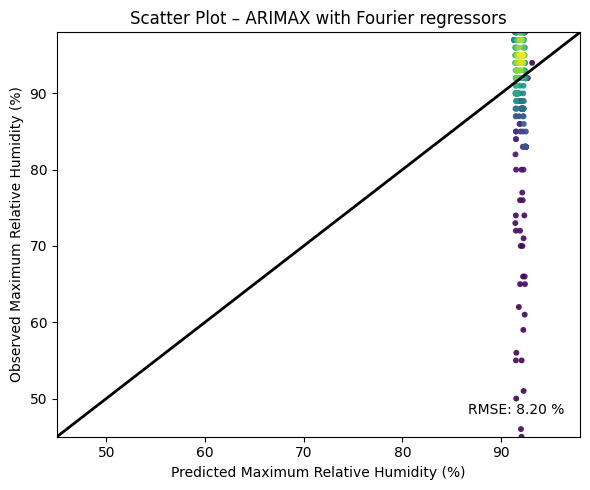

In [22]:
# --- ARIMAX + Fourier ---
n = len(df_training[forecast_parameter])  
t = np.arange(n)
seasonality = 365  

# Cria os termos de Fourier
def create_fourier_terms(t, period, num_terms):
    terms = []
    for i in range(1, num_terms + 1):
        terms.append(np.sin(2 * np.pi * i * t / period))
        terms.append(np.cos(2 * np.pi * i * t / period))
    return np.column_stack(terms)

num_fourier_terms = 4
fourier_terms = create_fourier_terms(t, seasonality, num_fourier_terms)

# Fit ARIMA model usando termos de Fourier como variáveis exógenas
model = ARIMA(df_training[forecast_parameter], exog=fourier_terms[:n], order=(2, 1, 3))
model_fit = model.fit()

# Prepara os termos de Fourier para o período de previsão
forecast_exog = create_fourier_terms(np.arange(n, n + len(df_test)), seasonality, num_fourier_terms)

# Prepare o DataFrame de variáveis exógenas para previsão
forecast_df = pd.DataFrame(forecast_exog, columns=[f'Fourier_{i+1}' for i in range(num_fourier_terms * 2)])

# Faz as previsões
forecast = model_fit.forecast(steps=len(df_test), exog=forecast_df)

# Cálculo de métricas de erro
mse = mean_squared_error(df_test[forecast_parameter], forecast)
rmse = mse**0.5 
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))

smape_value = smape(df_test[forecast_parameter], forecast)
print(f"SMAPE: {smape_value:.2f}%")

# Gráfico de dispersão
y_true = df_test[forecast_parameter].to_numpy()
y_pred = np.asarray(forecast).ravel()  
vmin = float(np.floor(min(y_true.min(), y_pred.min())))
vmax = float(np.ceil(max(y_true.max(), y_pred.max())))

fig, ax = plt.subplots(figsize=(6,5))

try:
    from scipy.stats import gaussian_kde
    xy = np.vstack([y_pred, y_true])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    ax.scatter(y_pred[idx], y_true[idx], c=z[idx], s=18, alpha=0.9,
               cmap="viridis", edgecolor="none")
except Exception:
    hb = ax.hexbin(y_pred, y_true, gridsize=35,
                   extent=[vmin, vmax, vmin, vmax],
                   cmap="viridis", mincnt=1)
    fig.colorbar(hb, ax=ax, label="Density")

ax.plot([vmin, vmax], [vmin, vmax], 'k-', lw=2)

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)
ax.set_xlabel("Predicted Maximum Relative Humidity (%)")
ax.set_ylabel("Observed Maximum Relative Humidity (%)")
ax.set_title("Scatter Plot – ARIMAX with Fourier regressors")  # troque pelo nome da estação se quiser
ax.text(0.97, 0.05, f"RMSE: {rmse:.2f} %",
        ha="right", va="bottom", transform=ax.transAxes)

plt.tight_layout()
plt.show()


In [23]:
df_training.corr()[forecast_parameter]

PRECIPITAÇÃO TOTAL, HORÁRIO (mm)                         0.316052
PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)   -0.392002
PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)         -0.389679
PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)        -0.393506
RADIACAO GLOBAL (KJ/m²)                                 -0.423737
TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)            -0.241809
TEMPERATURA DO PONTO DE ORVALHO (°C)                     0.801912
TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)              -0.271437
TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)              -0.207034
TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)         0.807367
TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)         0.797356
UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)                 0.816985
UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)                 0.785343
UMIDADE RELATIVA DO AR, HORARIA (%)                      1.000000
VENTO, DIREÇÃO HORARIA (gr) (° (gr))                     0.455073
VENTO, RAJ

/home/juliababa/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Raw RMSE: 6.570 | debias (ME): 6.537 | calib linear: 6.640
MSE: 42.72921449242075
RMSE: 6.536758714563415
sMAPE: 4.833292400782893


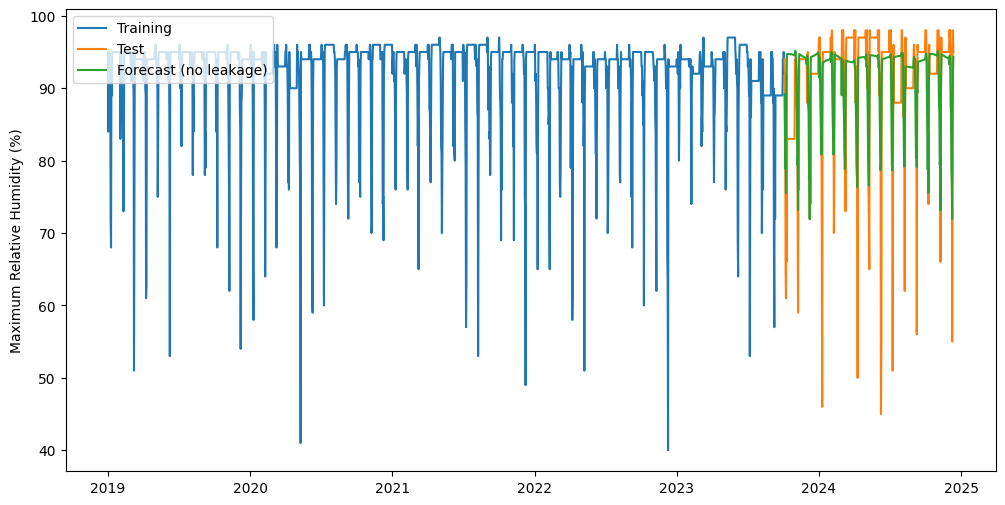

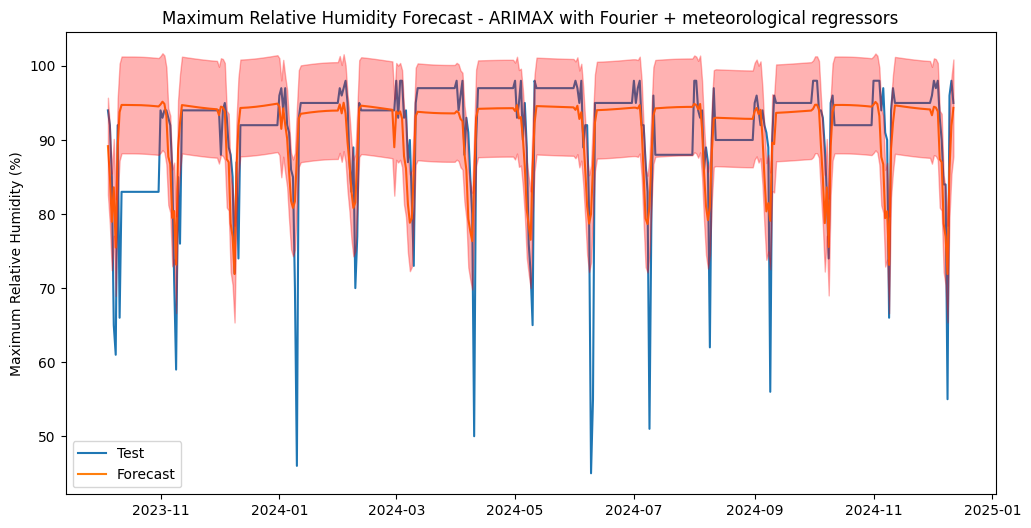

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import seaborn as sns
import statsmodels.api as sm

from pmdarima import auto_arima

def clean_data(dataframe):
    df = dataframe.copy()
    df['Data'] = pd.to_datetime(df['Data'], dayfirst=True, errors='coerce')
    hour = pd.to_numeric(df['Hora UTC'].astype(str).str.extract(r'^\s*(\d{2})')[0], errors='coerce').fillna(0).clip(0, 23).astype(int)
    df['datetime'] = df['Data'] + pd.to_timedelta(hour, unit='h')
    df = df.dropna(subset=['datetime']).sort_values('datetime').set_index('datetime')

    df_numeric = df.drop(columns=['Data', 'Hora UTC'])
    target_col = 'UMIDADE RELATIVA DO AR, HORARIA (%)'

    target_hourly = df_numeric[target_col].copy()

    df_daily = df_numeric.resample('D').mean()
    df_daily[target_col] = target_hourly.resample('D').max()
    df_not_null_values_day = df_daily.ffill().dropna(subset=[target_col])

    return df_not_null_values_day

def create_fourier_terms(t, period, num_terms):
    terms = []
    for i in range(1, num_terms + 1):
        terms.append(np.sin(2 * np.pi * i * t / period))
        terms.append(np.cos(2 * np.pi * i * t / period))
    return np.column_stack(terms)

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))


def get_forecast_test_graph(df_test, forecast, forecast_parameter, ax):
    import numpy as np
    from scipy import stats
    from sklearn.metrics import mean_squared_error
    import seaborn as sns

    values = np.vstack([df_test[forecast_parameter], forecast])
    kernel = stats.gaussian_kde(values)(values)

    sns.scatterplot(
        x=df_test[forecast_parameter],
        y=forecast,
        hue=kernel,
        palette="viridis",
        ax=ax,
        legend=False
    )

    mse = mean_squared_error(df_test[forecast_parameter], forecast)
    rmse = mse**0.5

    ax.plot(df_test[forecast_parameter], df_test[forecast_parameter], color='black', linewidth=1.0)

    ax.text(0.95, 0.05, f'RMSE: {rmse:.2f} %', ha='right', va='bottom', transform=ax.transAxes, fontsize=10)

    ax.set_ylabel('Observed Maximum Relative Humidity (%)')
    ax.set_xlabel('Predicted Maximum Relative Humidity (%)')

def arima_forecast_with_fourier_terms_exog(df_training, df_test, forecast_parameter, title, lag_days=365):
    n = len(df_training[forecast_parameter])
    t = np.arange(n)
    seasonality = 365
    num_fourier_terms = 4

    exog_vars = [
        "TEMPERATURA DO PONTO DE ORVALHO (°C)",
        "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"
    ]

    # Termos de fourier e variáveis exógenas do treino
    fourier_terms_train = create_fourier_terms(t, seasonality, num_fourier_terms)
    X_train_extra = df_training[exog_vars].values
    X_train_final = np.hstack([X_train_extra, fourier_terms_train[:n]])

     # Construção das variáveis exógenas do teste
    # perfil por (mês, dia): média de todos os anos do treino
    prof = df_training.copy()
    prof["__mm__"] = prof.index.month
    prof["__dd__"] = prof.index.day
    profile_mmdd = (
        prof.groupby(["__mm__", "__dd__"])[exog_vars]
        .mean() 
    )

    # índice (mês, dia) do teste 
    test_mm = pd.Index(df_test.index.month, name="__mm__")
    test_dd = pd.Index(df_test.index.day, name="__dd__")
    test_mmdd = pd.MultiIndex.from_arrays([test_mm, test_dd], names=["__mm__", "__dd__"])

    # mapeia (mês, dia) do teste -> média climatológica do treino
    X_test_extra_df = profile_mmdd.reindex(test_mmdd)

    # tratamento de datas 
    # fallback 1: média de (28/02) e (01/03)
    missing_rows = X_test_extra_df.isna().any(axis=1)
    if missing_rows.any():
        feb28 = profile_mmdd.reindex(pd.MultiIndex.from_arrays(
            [pd.Index([2], name="__mm__"), pd.Index([28], name="__dd__")]
        ))
        mar01 = profile_mmdd.reindex(pd.MultiIndex.from_arrays(
            [pd.Index([3], name="__mm__"), pd.Index([1], name="__dd__")]
        ))
        neigh_avg = (feb28.values + mar01.values) / 2.0 if (not feb28.isna().any().any() and not mar01.isna().any().any()) else None
        if neigh_avg is not None:
            X_test_extra_df.loc[missing_rows, exog_vars] = neigh_avg

    # fallback 2: perfil por dia-do-ano (módulo 365) do treino
    if X_test_extra_df.isna().any().any():
        prof_doy = df_training.copy()
        prof_doy["__doy__"] = prof_doy.index.dayofyear
        profile_doy = prof_doy.groupby("__doy__")[exog_vars].mean()
        test_doy = ((df_test.index.dayofyear - 1) % 365) + 1
        X_fallback_doy = profile_doy.reindex(test_doy).to_numpy()
        X_test_extra_df = X_test_extra_df.fillna(pd.DataFrame(
            X_fallback_doy, index=X_test_extra_df.index, columns=exog_vars
        ))

    # fallback 3: qualquer NaN remanescente -> média da coluna 
    if X_test_extra_df.isna().any().any():
        for col in exog_vars:
            X_test_extra_df[col].fillna(X_test_extra_df[col].mean(), inplace=True)

    X_test_extra = X_test_extra_df.to_numpy() 

    # fourier para o horizonte (com mesmo length do df_test) 
    forecast_steps = len(df_test)
    fourier_terms_test = create_fourier_terms(
        np.arange(n, n + forecast_steps),
        seasonality,
        num_fourier_terms
    )
    X_test_final = np.hstack([X_test_extra, fourier_terms_test])

    # Previsão 
    model = ARIMA(
        df_training[forecast_parameter],
        exog=X_train_final,
        order=(2,1,3),
        trend='n'
    )
    model_fit = model.fit()

    forecast_vals = model_fit.forecast(steps=forecast_steps, exog=X_test_final)

    cal = debias_with_calibration(model_fit, df_training, forecast_parameter, X_train_final, forecast_vals, calib_days=60)
    rmse_raw = mean_squared_error(df_test[forecast_parameter], forecast_vals)**0.5
    rmse_bias = mean_squared_error(df_test[forecast_parameter], cal["forecast_bias_fixed"])**0.5
    rmse_lin  = mean_squared_error(df_test[forecast_parameter], cal["forecast_linear_cal"])**0.5

    print(f"Raw RMSE: {rmse_raw:.3f} | debias (ME): {rmse_bias:.3f} | calib linear: {rmse_lin:.3f}")

    forecast_corrected = cal["forecast_bias_fixed"]

    # Plot dos resultados
    plt.figure(figsize=(12, 6))
    plt.plot(df_training.index, df_training[forecast_parameter], label='Training')
    plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
    plt.plot(df_test.index, forecast_corrected, label='Forecast (no leakage)')
    plt.ylabel('Maximum Relative Humidity (%)')
    plt.legend(loc='upper left')

    # Cálculo métricas de erro

    mse = mean_squared_error(df_test[forecast_parameter], forecast_corrected)
    rmse = mse ** 0.5
    smape_value = smape(df_test[forecast_parameter], forecast_corrected)
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'sMAPE: {smape_value}')

    plt.figure(figsize=(12,6))
    plt.plot(df_test.index, df_test[forecast_parameter], label='Test')
    plt.plot(df_test.index, forecast_corrected, label='Forecast')
    plt.ylabel('Maximum Relative Humidity (%)')
    plt.legend(loc='upper left')
    plt.title(f"Maximum Relative Humidity Forecast - ARIMAX with Fourier + meteorological regressors")
    plt.legend()
    plt.fill_between(df_test.index, (forecast_corrected-rmse), (forecast_corrected+rmse), alpha=.3, color='r', zorder=20)


    return pd.Series(forecast_corrected, index=df_test.index, name='forecast')


def debias_with_calibration(model_fit, df_training, forecast_parameter, X_train_final, forecast_vals, calib_days=60):
    # previsões 1-passo à frente na cauda do TREINO (janela de calibração)
    start = len(df_training) - calib_days
    pred_cal = model_fit.get_prediction(
        start=df_training.index[start],
        end=df_training.index[-1],
        exog=X_train_final[start:]
    ).predicted_mean
    y_cal = df_training[forecast_parameter].iloc[start:]

    # medir viés (ME) e corrigir por deslocamento 
    ME = (y_cal - pred_cal).mean()
    forecast_bias_fixed = forecast_vals + ME

    # correção linear (intercepto + inclinação)
    X = sm.add_constant(pred_cal.values)
    a, b = sm.OLS(y_cal.values, X).fit().params
    forecast_linear_cal = a + b * forecast_vals

    return {
        "ME": ME,
        "forecast_bias_fixed": forecast_bias_fixed,
        "a": a, "b": b,
        "forecast_linear_cal": forecast_linear_cal
    }

forecast_parameter = 'UMIDADE RELATIVA DO AR, HORARIA (%)'

forecast = arima_forecast_with_fourier_terms_exog(df_training, df_test, forecast_parameter, f'Maximum Relative Humidity Forecast - ARIMAX with Fourier + meteorological regressors')
